In [43]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
df = pd.read_csv(r'C:\Users\orams\Documents\Customer-Churn-Prediction\data\processed_data\telco_churn_ml_ready.csv')
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,NumServices,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_13-24 months,TenureGroup_25-48 months,TenureGroup_49-72 months,HasInternetService_Yes,Churn
0,0,-1.277445,-1.160323,-0.992611,-1.145997,False,True,False,False,True,...,False,True,False,True,False,False,False,False,True,No
1,0,0.066327,-0.259629,-0.172165,-0.176011,True,False,False,True,False,...,False,False,False,False,True,False,True,False,True,No
2,0,-1.236724,-0.362660,-0.958066,-0.176011,True,False,False,True,False,...,False,True,False,False,True,False,False,False,True,Yes
3,0,0.514251,-0.746535,-0.193672,-0.176011,True,False,False,False,True,...,False,False,False,False,False,False,True,False,True,No
4,0,-1.236724,0.197365,-0.938874,-1.145997,False,False,False,True,False,...,False,True,False,True,False,False,False,False,True,Yes


In [26]:
#Separating features and target 

In [27]:
X = df.drop(columns=['Churn'])
y = df['Churn']

In [28]:
#Train-test split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [30]:
#VERIFYING THE SPLIT
print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(5634, 35) (1409, 35)
Churn
No     0.734647
Yes    0.265353
Name: proportion, dtype: float64
Churn
No     0.734564
Yes    0.265436
Name: proportion, dtype: float64


In [31]:
#BUILDING THE BASELINE MODEL

In [32]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

Generate predictions on the test set

In [33]:
y_pred = log_model.predict(X_test)
y_pred_proba = log_model.predict_proba(X_test)[:, 1]

In [34]:
#EVALUATING WITH ALL REQUIRED METRICvS

In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, pos_label='Yes'))
print("Recall:", recall_score(y_test, y_pred, pos_label='Yes'))
print("F1-score:", f1_score(y_test, y_pred, pos_label='Yes'))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7998580553584103
Precision: 0.6554054054054054
Recall: 0.5187165775401069
F1-score: 0.5791044776119403
ROC-AUC: 0.8424345759384122

Confusion Matrix:
 [[933 102]
 [180 194]]


In [36]:
#BUILDING DECISION TREE MODEL

In [37]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)
y_pred_proba_tree = tree_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Precision:", precision_score(y_test, y_pred_tree, pos_label='Yes'))
print("Recall:", recall_score(y_test, y_pred_tree, pos_label='Yes'))
print("F1-score:", f1_score(y_test, y_pred_tree, pos_label='Yes'))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_tree))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_tree))

Accuracy: 0.7359829666430092
Precision: 0.5028409090909091
Recall: 0.4732620320855615
F1-score: 0.48760330578512395
ROC-AUC: 0.6515810276679841

Confusion Matrix:
 [[860 175]
 [197 177]]


In [38]:
#RANDOM FOREST MODEL

In [39]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, pos_label='Yes'))
print("Recall:", recall_score(y_test, y_pred_rf, pos_label='Yes'))
print("F1-score:", f1_score(y_test, y_pred_rf, pos_label='Yes'))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.7849538679914834
Precision: 0.6263345195729537
Recall: 0.47058823529411764
F1-score: 0.5374045801526718
ROC-AUC: 0.8182231522384975

Confusion Matrix:
 [[930 105]
 [198 176]]


Initial Model Selection

Based on the 3 models, I would select Logistic Regression. My reason is that it has the highest recall at 51.9% compared with the rest, it also has the highest F1-score at 57.9% compared with the rest, and it also has the highest ROC-AUC at 84.2% compared to the rest. Accuracy alone is not enough because the dataset contains substantially more non-churners than churners.

So, Logistic Regression is my initial model selection, while Random Forest remains a reasonable alternative that could be revisited during Week 4 hyperparameter tuning.

This is an initial selection, not the final model. Week 4's tuning and cross-validation could change the comparison.

In [40]:
#COMPARISON TABLE

In [41]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [0.7999, 0.7360, 0.7850],
    'Precision': [0.6554, 0.5028, 0.6263],
    'Recall': [0.5187, 0.4733, 0.4706],
    'F1-Score': [0.5791, 0.4876, 0.5374],
    'ROC-AUC': [0.8424, 0.6516, 0.8182]
})
comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7999,0.6554,0.5187,0.5791,0.8424
1,Decision Tree,0.7360,0.5028,0.4733,0.4876,0.6516
2,Random Forest,0.7850,0.6263,0.4706,0.5374,0.8182


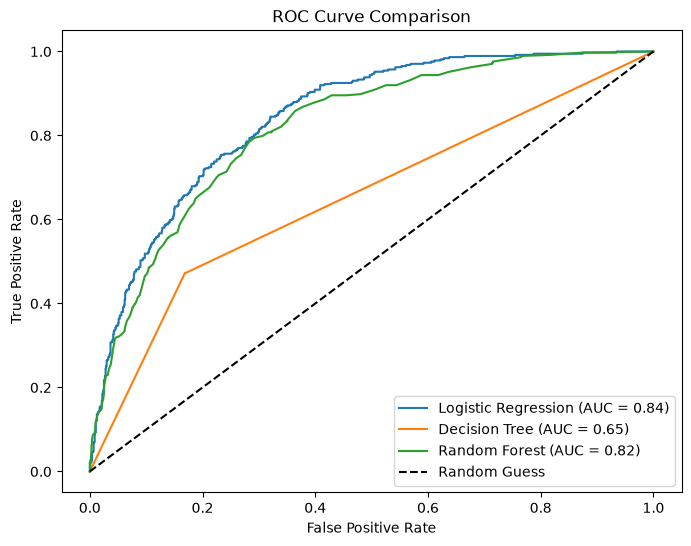

In [44]:
#ROC CURVE
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))

for model_name, proba in [('Logistic Regression', y_pred_proba), 
                           ('Decision Tree', y_pred_proba_tree), 
                           ('Random Forest', y_pred_proba_rf)]:
    fpr, tpr, _ = roc_curve(y_test, proba, pos_label='Yes')
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()